In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from pd_estim_A.data.data_import import (
    load_data, load_ecb_1y_yield,
    fill_liabilities, drop_high_leverage_firms,
    prepare_merton_inputs, prepare_nig_inputs
)

from pd_estim_A.models.nig.nig_apath import NIGParams, invert_assets_weekly_for_firm
from pd_estim_A.models.nig.nig_em import fit_nig_params_from_weekly_assets
from pd_estim_A.models.nig.nig_pd import pd_weekly_one_firm
from pd_estim_A.data.cds_df import get_cds_panel

In [2]:
# Paths
print(Path.cwd())
data_path = Path.cwd() / ".." / "data" / "raw"
output_path = Path.cwd() / ".." / "data" / "derived"

# Load data and prepare panels
ret_daily, bs, coverage = load_data(
    data_path / "Jan2025_Accenture_Dataset_ErasmusCase.xlsx",
    start_date="2012-01-01",
    end_date="2025-12-19",
    enforce_coverage=True,
    coverage_tol=0.995,
    liabilities_scale="auto",
    verbose=True,
)

df_rf = load_ecb_1y_yield(
    startPeriod="2010-01-01",
    endPeriod="2025-12-31",
    out_file= output_path / "ecb_yc_1y_aaa.xml",
    verify_ssl=True,  # recommended if it works
)

df_cal = ret_daily[["date"]].drop_duplicates().sort_values("date").reset_index(drop=True)

debt_daily = fill_liabilities(bs, df_cal)

ret_filt, bs_filt, lev_by_firm, dropped = drop_high_leverage_firms(
    ret_daily,
    bs,
    df_calendar=df_cal,
    debt_daily=debt_daily,
    lev_threshold=8.0,
    lev_agg="median",
    verbose=True,
)

# keep debt panel consistent with filtered firms
keep = set(ret_filt["gvkey"].astype(str).unique())
debt_daily_filt = debt_daily[debt_daily["gvkey"].astype(str).isin(keep)].copy()


nig_df, em_cache = prepare_nig_inputs(ret_filt, bs_filt, df_rf, debt_daily=debt_daily_filt, build_em=False)
print(nig_df.head())
print(nig_df.shape)
print(nig_df.describe())

c:\Users\vkeenan\OneDrive - Delft University of Technology\Documents\University\QRM\Accenture Project\code\notebooks_test
[load_data] Firms (ret_daily): 46
[load_data] Date range (ret_daily): 2012-01-03 .. 2025-12-19
[load_data] Coverage min/median/max: 0.999 / 1.000 / 1.000
[load_data] liabilities_scale_used: 1e+06
[load_data] QA mcap_reported<=0 rows (raw windowed mkt): 62
Data has been written to c:\Users\vkeenan\OneDrive - Delft University of Technology\Documents\University\QRM\Accenture Project\code\notebooks_test\..\data\derived\ecb_yc_1y_aaa.xml
[drop_high_leverage_firms] agg=median, threshold=8.0
[drop_high_leverage_firms] firms before: 46 | after: 36
[drop_high_leverage_firms] dropped firms: 10
    gvkey       date             E          isin  \
0  100022 2012-01-03  3.328431e+10  DE0005190003   
1  100080 2012-01-03  4.268705e+10  DE000BAY0017   
2  100312 2012-01-03  1.469717e+09  DE0007030009   
3  100581 2012-01-03  4.935351e+10  FR0000120321   
4  100957 2012-01-03  2.931

In [3]:
# call cds panel and merge
cds = get_cds_panel(
    project_root= Path.cwd() / "..",
    save_csv=False,
    verbose=True,
)
# ensure types
merton = nig_df.copy()
merton["gvkey"] = merton["gvkey"].astype(str)
merton["date"]  = pd.to_datetime(merton["date"])

cds["gvkey"] = cds["gvkey"].astype(str)
cds["date"]  = pd.to_datetime(cds["date"])

# keep only firms that exist in BOTH (drop firms with no CDS)
common_gv = sorted(set(merton["gvkey"].unique()) & set(cds["gvkey"].unique()))
merton = merton[merton["gvkey"].isin(common_gv)].copy()
cds = cds[cds["gvkey"].isin(common_gv)].copy()

# also drop CDS rows whose dates are outside merged's date range
dmin, dmax = merton["date"].min(), merton["date"].max()
cds = cds[(cds["date"] >= dmin) & (cds["date"] <= dmax)].copy()

# merge-asof onto merged's dates (direction='backward')
merton = merton.sort_values(["date", "gvkey"]).reset_index(drop=True)
cds    = cds.sort_values(["date", "gvkey"]).reset_index(drop=True)

merged_cds = pd.merge_asof(
    merton,
    cds,
    on="date",
    by="gvkey",
    direction="backward",
    allow_exact_matches=True,
)

# drop rows where CDS still missing
nig_df = merged_cds.dropna(subset=["cds"]).reset_index(drop=True)

print("firms after intersection:", nig_df["gvkey"].nunique())
print("rows after merge:", len(nig_df))
print("date range:", nig_df["date"].min(), "→", nig_df["date"].max())

[load_data] Firms (ret_daily): 46
[load_data] Date range (ret_daily): 2012-01-03 .. 2025-12-19
[load_data] Coverage min/median/max: 0.999 / 1.000 / 1.000
[load_data] liabilities_scale_used: 1e+06
[load_data] QA mcap_reported<=0 rows (raw windowed mkt): 62
[get_cds_panel] sheets read: 22 | rows parsed: 67015 | unmapped sheets: 0
firms after intersection: 21
rows after merge: 65569
date range: 2014-01-01 00:00:00 → 2025-12-19 00:00:00


In [4]:
# Global settings
P0 = NIGParams(alpha=15.0, beta=-3.0, delta=0.20, mu=0.00)
INVERT_U = 120.0
INVERT_N = 2000

WINDOW_WEEKS = 104
REFIT_EVERY = 13
HORIZON_WEEKS = 52.0

PD_START = pd.Timestamp("2014-01-01")

# Identify firms
gvkeys = (
    nig_df["gvkey"]
    .astype(str)
    .dropna()
    .unique()
)
gvkeys = sorted(gvkeys)

print("n_firms:", len(gvkeys), "date span:", nig_df["date"].min(), "→", nig_df["date"].max())

n_firms: 21 date span: 2014-01-01 00:00:00 → 2025-12-19 00:00:00


In [5]:
# Storage
assets_by_firm = {}     # gvkey -> weekly assets df
updates_by_firm = {}    # gvkey -> quarterly updates df
pds_by_firm = {}        # gvkey -> weekly pd df

run_log = []            # per-firm timing + basic QC

t0_all = time.time()

for k, gv in enumerate(gvkeys, 1):
    t0 = time.time()

    g = nig_df.loc[nig_df["gvkey"].astype(str) == gv].sort_values("date").copy()
    if g.empty:
        continue

    # Step 1: weekly inversion
    try:
        assets_w = invert_assets_weekly_for_firm(g, P0, U=INVERT_U, n=INVERT_N)
    except Exception as e:
        run_log.append({"gvkey": gv, "status": "FAIL_INVERT", "err": str(e)})
        continue

    # basic QC
    nan_A = int(assets_w["A_hat"].isna().sum())
    n_weeks = int(len(assets_w))

    # Step 2: quarterly refit (on weekly dlogA, theta-aware)
    try:
        upd = fit_nig_params_from_weekly_assets(
            assets_w,
            p0=P0,
            window_weeks=WINDOW_WEEKS,
            refit_every=REFIT_EVERY,
            use_theta=True,
            prefer_precomputed_theta=True,  # you already have theta from inversion
            verbose=False,                  # switch True if debugging one firm
        )
    except Exception as e:
        run_log.append({"gvkey": gv, "status": "FAIL_EM", "err": str(e), "weeks": n_weeks, "nan_A": nan_A})
        continue

    # Step 3: weekly PD from 2014 onward
    try:
        assets_pd = assets_w.loc[assets_w["date"] >= PD_START].copy()
        pd_w = pd_weekly_one_firm(
            assets_pd,
            gvkey=str(gv),
            param_updates=upd,
            p0=P0,
            horizon_weeks=HORIZON_WEEKS,
        )
    except Exception as e:
        run_log.append({"gvkey": gv, "status": "FAIL_PD", "err": str(e), "weeks": n_weeks, "nan_A": nan_A})
        continue

    # store
    assets_by_firm[gv]  = assets_w.assign(gvkey=str(gv))
    updates_by_firm[gv] = upd.assign(gvkey=str(gv))
    pds_by_firm[gv]     = pd_w.assign(gvkey=str(gv))

    # quick PD QC
    pd_nan = float(pd_w["PD_1y"].isna().mean())
    pd_min = float(pd_w["PD_1y"].min())
    pd_max = float(pd_w["PD_1y"].max())

    run_log.append({
        "gvkey": gv,
        "status": "OK",
        "weeks": n_weeks,
        "nan_A": nan_A,
        "n_updates": int(len(upd)),
        "pd_rows": int(len(pd_w)),
        "pd_nan_share": pd_nan,
        "pd_min": pd_min,
        "pd_max": pd_max,
        "sec": time.time() - t0,
    })

    if (k % 10) == 0:
        ok_count = sum(r["status"] == "OK" for r in run_log)
        print(f"[{k}/{len(gvkeys)}] last gv={gv} | OK={ok_count} | last_sec={run_log[-1].get('sec',np.nan):.2f}")

print("Total runtime (sec):", time.time() - t0_all)

[10/21] last gv=17436 | OK=10 | last_sec=3.72
[20/21] last gv=241456 | OK=20 | last_sec=3.25
Total runtime (sec): 73.9510600566864


In [6]:
assets_weekly_all = pd.concat(assets_by_firm.values(), ignore_index=True)
updates_all = pd.concat(
    [df.assign(gvkey=str(gv)) for gv, df in updates_by_firm.items()],
    ignore_index=True
)
pds_weekly_all = pd.concat(pds_by_firm.values(), ignore_index=True)

log_df = pd.DataFrame(run_log).sort_values(["status", "sec"], ascending=[True, False])

print("assets_weekly_all:", assets_weekly_all.shape)
print("updates_all:", updates_all.shape)
print("pds_weekly_all:", pds_weekly_all.shape)
log_df["status"].value_counts()

assets_weekly_all: (13125, 9)
updates_all: (861, 13)
pds_weekly_all: (13125, 9)


status
OK    21
Name: count, dtype: int64

In [7]:
print(pds_weekly_all.keys())
print(updates_all.keys())
print(assets_weekly_all.keys())


Index(['gvkey', 'date', 'A_hat', 'L', 'alpha', 'beta', 'delta', 'mu', 'PD_1y'], dtype='object')
Index(['date', 'alpha', 'beta', 'delta', 'mu', 'emp_mean', 'mod_mean',
       'emp_std', 'mod_std', 'alpha_required_from_theta', 'alpha_hits_floor',
       'window_len', 'gvkey'],
      dtype='object')
Index(['date', 'E', 'L', 'r', 'A_hat', 'theta', 'logA', 'dlogA', 'gvkey'], dtype='object')


In [8]:
pds_weekly_all["PD_1y"].between(0,1).all(), pds_weekly_all["PD_1y"].isna().mean()
pds_weekly_all["PD_1y"].describe(percentiles=[0.5,0.9,0.95,0.99,0.995,0.999])

count    1.312500e+04
mean     1.561196e-01
std      3.411335e-01
min      4.514131e-09
50%      1.380546e-03
90%      9.051231e-01
95%      9.652242e-01
99%      9.797502e-01
99.5%    9.843815e-01
99.9%    9.855948e-01
max      9.874687e-01
Name: PD_1y, dtype: float64

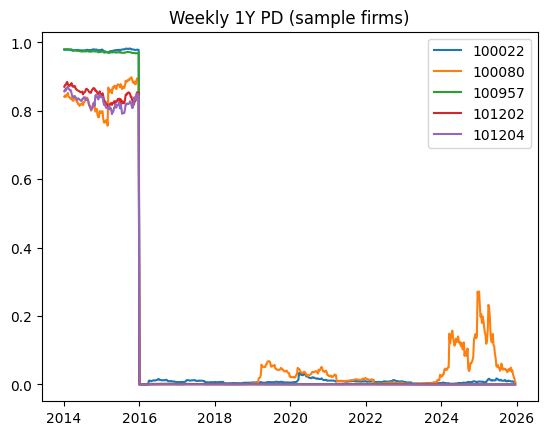

In [9]:
import matplotlib.pyplot as plt

sample_gv = list(pds_by_firm.keys())[:5]
plt.figure()
for gv in sample_gv:
    d = pds_by_firm[gv]
    plt.plot(d["date"], d["PD_1y"], label=gv)
plt.title("Weekly 1Y PD (sample firms)")
plt.legend()
plt.show()

In [10]:
top = (pds_weekly_all
       .sort_values("PD_1y", ascending=False)
       .head(30))
top

,gvkey,date,A_hat,L,alpha,beta,delta,mu,PD_1y
7500,201794,2014-01-03,1.482645e+11,1.184980e+11,15.0,-3.0,0.2,0.0,0.987469
7501,201794,2014-01-10,1.491329e+11,1.184980e+11,15.0,-3.0,0.2,0.0,0.987240
7502,201794,2014-01-17,1.500318e+11,1.184980e+11,15.0,-3.0,0.2,0.0,0.987002
7503,201794,2014-01-24,1.501873e+11,1.184980e+11,15.0,-3.0,0.2,0.0,0.986960
7504,201794,2014-01-31,1.503126e+11,1.184980e+11,15.0,-3.0,0.2,0.0,0.986927
7505,201794,2014-02-07,1.519394e+11,1.184980e+11,15.0,-3.0,0.2,0.0,0.986487
7553,201794,2015-01-09,1.439571e+11,1.113090e+11,15.0,-3.0,0.2,0.0,0.986126
7506,201794,2014-02-14,1.532616e+11,1.184980e+11,15.0,-3.0,0.2,0.0,0.986124
7508,201794,2014-02-28,1.533752e+11,1.184980e+11,15.0,-3.0,0.2,0.0,0.986093
7507,201794,2014-02-21,1.537601e+11,1.184980e+11,15.0,-3.0,0.2,0.0,0.985986


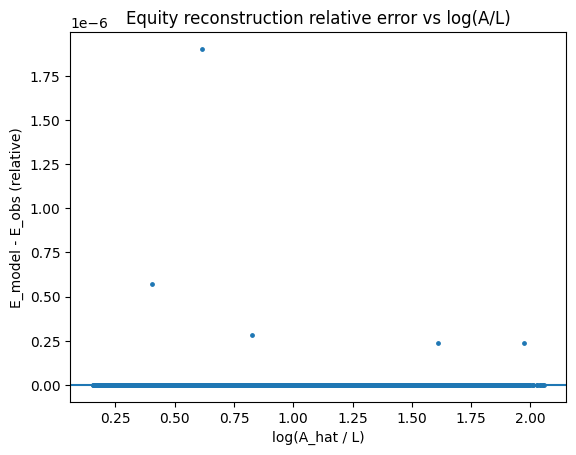

count    1.094100e+04
mean     2.955781e-10
std      1.947058e-08
min      0.000000e+00
50%      0.000000e+00
90%      2.058119e-16
95%      2.464705e-16
99%      3.512007e-16
99.9%    4.247376e-16
max      1.904591e-06
Name: E_rel_err, dtype: float64
share |rel_err| > 5e-4: 0.0


,gvkey,n,share_|z|>thr,max_|ret|,top1pct_energy_share
17,23667,624,0.004808,0.320364,0.594564
12,201794,624,0.004808,0.202976,0.574786
15,221616,624,0.003205,0.297748,0.620509
18,23671,624,0.003205,0.304641,0.428607
20,61616,624,0.003205,0.169264,0.404022
1,100080,624,0.001603,0.377363,0.483121
0,100022,624,0.001603,0.106333,0.362865
10,17452,624,0.001603,0.164799,0.290667
13,220940,624,0.001603,0.084867,0.266857
3,101202,624,0.001603,0.174538,0.264801


,date,dlogA,robust_z,abs_ret
2831,2016-07-29,0.320364,24.708821,0.320364
3503,2017-03-10,0.239686,18.451968,0.239686
6758,2020-02-28,0.138226,10.583388,0.138226
1655,2015-07-03,-0.086950,-6.879775,0.086950
6800,2020-03-13,-0.084262,-6.671309,0.084262
3797,2017-06-16,-0.076800,-6.092576,0.076800
8963,2022-03-04,0.073937,5.597588,0.073937
1298,2015-03-06,0.069286,5.236837,0.069286
5330,2018-11-09,0.060274,4.537963,0.060274
542,2014-06-27,-0.056617,-4.527331,0.056617


median refit / nonrefit abs logit jump ratio: 1.4718806853070017
refit abs dlogit summary:
 count    2561.000000
mean        0.320967
std         1.498535
min         0.000012
50%         0.077279
90%         0.431982
95%         0.740558
99%         6.808981
max        20.586487
Name: dlogit_pd, dtype: float64
non-refit abs dlogit summary:
 count    534703.000000
mean          0.125280
std           0.669457
min           0.000001
50%           0.052504
90%           0.209058
95%           0.326802
99%           0.826094
max          20.586487
Name: dlogit_pd, dtype: float64


,gvkey,date,PD_1y,pd_prev,dlogit_pd,is_refit_week,refit_date,refit_dist_days
81139,101202,2016-01-01,6.631603e-09,0.852591,-20.586487,True,2016-01-01,0
81140,101202,2016-01-01,6.631603e-09,0.852591,-20.586487,False,2016-04-01,91
81141,101202,2016-01-01,6.631603e-09,0.852591,-20.586487,False,2016-07-01,182
81142,101202,2016-01-01,6.631603e-09,0.852591,-20.586487,False,2016-09-30,273
81143,101202,2016-01-01,6.631603e-09,0.852591,-20.586487,False,2016-12-30,364
81144,101202,2016-01-01,6.631603e-09,0.852591,-20.586487,False,2017-03-31,455
81145,101202,2016-01-01,6.631603e-09,0.852591,-20.586487,False,2017-06-30,546
81146,101202,2016-01-01,6.631603e-09,0.852591,-20.586487,False,2017-09-29,637
81147,101202,2016-01-01,6.631603e-09,0.852591,-20.586487,False,2017-12-29,728
81148,101202,2016-01-01,6.631603e-09,0.852591,-20.586487,False,2018-03-30,819


In [11]:
from pd_estim_A.models.nig.nig_safety import (
    check_equity_reconstruction_errors,
    check_asset_return_outliers,
    check_refit_date_jumps,
    compare_two_pd_panels,
)

assets_weekly_all = assets_weekly_all.copy()
updates_all = updates_all.copy()

assets_weekly_all["date"] = pd.to_datetime(assets_weekly_all["date"])
updates_all["date"] = pd.to_datetime(updates_all["date"])
assets_weekly_all["gvkey"] = assets_weekly_all["gvkey"].astype(str)
updates_all["gvkey"] = updates_all["gvkey"].astype(str)

# drop bad dates (merge_asof restrictions)
assets_weekly_all = assets_weekly_all.dropna(subset=["date", "gvkey"])
updates_all = updates_all.dropna(subset=["date", "gvkey"])
assets_weekly_all = assets_weekly_all.sort_values(["date", "gvkey"]).reset_index(drop=True)
updates_all = updates_all.sort_values(["date", "gvkey"]).reset_index(drop=True)

assets_weekly_with_params = pd.merge_asof(
    assets_weekly_all,
    updates_all[["gvkey", "date", "alpha", "beta", "delta", "mu"]],
    on="date",
    by="gvkey",
    direction="backward",
    allow_exact_matches=True,
)

# resrict to rows where we have all parameters
assets_weekly_with_params = assets_weekly_with_params.loc[
    assets_weekly_with_params["alpha"].notna()
].copy()

# (i) Equity reconstruction errors
eq = check_equity_reconstruction_errors(
    assets_weekly_with_params,
    tau_inv=1.0,
    use_theta_col="theta",
    max_abs_rel_err_warn=5e-4,
    plot=True,
)
print(eq["summary_abs_rel_error"])
print("share |rel_err| > 5e-4:", eq["share_abs_rel_err_gt_thresh"])

# (ii) Return outliers (dlogA)
tails = check_asset_return_outliers(
    assets_weekly_all,
    ret_col="dlogA",
    z_thresh=10.0,
    topk=10,
)
display(tails["worst_firms"])
# inspect one flagged firm
bad_gv = tails["worst_firms"].iloc[0]["gvkey"]
ex = [r for r in tails["per_firm"] if r["gvkey"] == bad_gv][0]["examples_top_outliers"]
display(ex)

# (iii) Jumps at refit dates (PD discontinuities)
jumps = check_refit_date_jumps(
    pds_weekly_all,
    updates_all,
    pd_col="PD_1y",
    refit_merge_tol_days=7,
)
print("median refit / nonrefit abs logit jump ratio:", jumps["ratio_median_refit_to_nonrefit"])
print("refit abs dlogit summary:\n", jumps["abs_dlogit_pd_refit_desc"])
print("non-refit abs dlogit summary:\n", jumps["abs_dlogit_pd_nonrefit_desc"])
display(jumps["top_abs_jumps"])

In [12]:
# save final_df as CSV in the current working directory
output_path = Path.cwd() / ".." / "data" / "derived"
pds_weekly_all.to_csv(output_path / "NIG_weekly.csv", index=False)